# Pre/Post Steer Feature Activations By Sample
For each selected feature, plot pre and post steering activation across test samples, colored by correctness. Supports FEAT scalar metadata and SPARE top_idx list metadata.

In [7]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

In [8]:
# Update this path to result JSON that includes per-sample steer metadata
RESULT_JSON_PATH = Path('Results/feat/eval_gemma_refusal_response_feat_14509.0_coeff_15_20260410_234635.json')
MAX_FEATURES_TO_PLOT = None  # set int to limit number of feature subplots

In [9]:
with RESULT_JSON_PATH.open('r', encoding='utf-8') as f:
    payload = json.load(f)

def as_list(value):
    if value is None:
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    return [value]

config = payload.get('config', {}) or {}
steer_cfg = config.get('steer', {}) or {}
result = payload.get('result', {}) or {}
samples = result.get('samples', []) or []

layer_list = as_list(result.get('layer'))
layer_key = str(layer_list[0]) if layer_list else None
feature_list_cfg = steer_cfg.get('feature_list')
default_feature_idx = []
if isinstance(feature_list_cfg, dict):
    if layer_key is not None and layer_key in feature_list_cfg:
        default_feature_idx = as_list(feature_list_cfg.get(layer_key))
    elif layer_key is not None and layer_key.isdigit() and int(layer_key) in feature_list_cfg:
        default_feature_idx = as_list(feature_list_cfg.get(int(layer_key)))
    elif len(feature_list_cfg) == 1:
        default_feature_idx = as_list(next(iter(feature_list_cfg.values())))

rows = []
for sample_idx, s in enumerate(samples):
    meta = s.get('metadata', {}) or {}
    correct = int(s.get('is_correct', 0))

    feat_idx = as_list(meta.get('steering_idx'))
    if not feat_idx:
        feat_idx = as_list(meta.get('feature_index'))
    if not feat_idx and default_feature_idx:
        feat_idx = list(default_feature_idx)

    pre_vals = as_list(meta.get('pre_steer_feat_act'))
    if not pre_vals:
        pre_vals = as_list(meta.get('pre_steer_top_idx_acts'))

    post_vals = as_list(meta.get('post_steer_feat_act'))
    if not post_vals:
        post_vals = as_list(meta.get('post_steer_top_idx_acts'))

    max_len = max(len(feat_idx), len(pre_vals), len(post_vals))
    if max_len == 0:
        continue

    if len(feat_idx) == 0:
        feat_idx = [None] * max_len
    elif len(feat_idx) == 1 and max_len > 1:
        feat_idx = feat_idx * max_len

    if len(pre_vals) == 1 and max_len > 1:
        pre_vals = pre_vals * max_len
    if len(post_vals) == 1 and max_len > 1:
        post_vals = post_vals * max_len

    n = min(len(feat_idx), len(pre_vals), len(post_vals))
    if n == 0:
        continue

    for i in range(n):
        raw_fidx = feat_idx[i]
        fidx = int(raw_fidx) if raw_fidx is not None else -1
        rows.append({
            'sample_idx': sample_idx,
            'feature_index': fidx,
            'stage': 'pre',
            'activation': float(pre_vals[i]),
            'is_correct': correct,
        })
        rows.append({
            'sample_idx': sample_idx,
            'feature_index': fidx,
            'stage': 'post',
            'activation': float(post_vals[i]),
            'is_correct': correct,
        })

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError('No usable pre/post steer activation metadata found in this result file.')

display(df.head())
print(f'n_rows = {len(df)}; n_features = {df.feature_index.nunique()}')

,sample_idx,feature_index,stage,activation,is_correct
0,0,14509,pre,0.0,1
1,0,14509,post,160.0,1
2,1,14509,pre,0.0,1
3,1,14509,post,160.0,1
4,2,14509,pre,0.0,1


n_rows = 100; n_features = 1


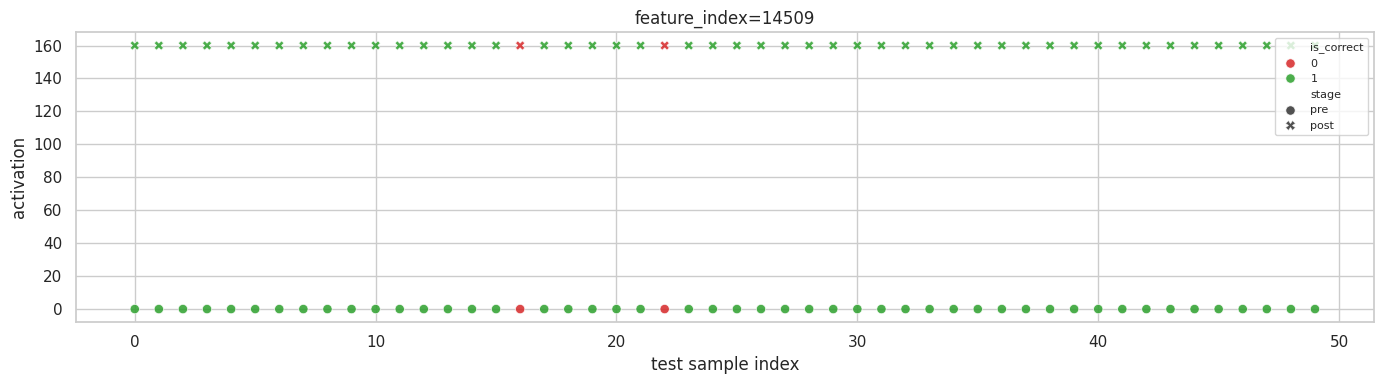

In [10]:
feature_ids = sorted(df['feature_index'].unique())
if MAX_FEATURES_TO_PLOT is not None:
    feature_ids = feature_ids[:int(MAX_FEATURES_TO_PLOT)]

n = len(feature_ids)
if n == 0:
    raise ValueError('No feature ids to plot.')

fig, axes = plt.subplots(n, 1, figsize=(14, max(4, 2.8 * n)), sharex=True)
if n == 1:
    axes = [axes]

palette = {0: '#d62728', 1: '#2ca02c'}
for ax, fid in zip(axes, feature_ids):
    sub = df[df['feature_index'] == fid].copy()
    sns.scatterplot(
        data=sub,
        x='sample_idx',
        y='activation',
        hue='is_correct',
        style='stage',
        palette=palette,
        alpha=0.85,
        s=45,
        ax=ax,
    )
    title_fid = 'unknown' if fid == -1 else str(fid)
    ax.set_title(f'feature_index={title_fid}')
    ax.set_ylabel('activation')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('test sample index')
plt.tight_layout()
plt.show()